# A1.2 From prevalence to observed cases

A fraction $p = 0.10$ of all new infections is reported, and $C(t)$ is the cumulative number of reported cases up to time $t$. Parameters: $N = 10^5$, $i_0 = 10$, $\mathcal{R}_0 = 1.5$, $\alpha = 1$.

## (a) Integral form of $C(t)$ and the augmented system

New infections occur at the incidence rate $\beta s i / N$ from Eq. (1). With $\alpha = 1$ we have $\beta = \mathcal{R}_0$, and $s = N - i$, so

$$
C(t) = p \int_0^t \mathcal{R}_0 \frac{\big(N - i(\tau)\big)\, i(\tau)}{N}\, d\tau , \qquad C(0) = 0.
$$

Differentiating gives the extra equation to append to Eq. (2):

$$
\begin{aligned}
\frac{di}{dt} &= (\mathcal{R}_0 - 1)\, i - \mathcal{R}_0 \frac{i^2}{N}, \\
\frac{dC}{dt} &= p\, \mathcal{R}_0 \frac{(N - i)\, i}{N},
\end{aligned}
\qquad (i, C)(0) = (i_0, 0).
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 1e5
i0 = 10.0
R0 = 1.5
p = 0.10
K = N * (1 - 1 / R0)   # endemic level of i


def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h / 2, y + h / 2 * k1)
    k3 = f(t + h / 2, y + h / 2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def integrate(step_fn, f, y0, T, M):
    """Vector version of the 1.1 integrator: returns t (M+1,) and y (M+1, d)."""
    h = T / M
    t = np.linspace(0, T, M + 1)
    y0 = np.atleast_1d(np.asarray(y0, dtype=float))
    y = np.empty((M + 1, y0.size))
    y[0] = y0
    for j in range(M):
        y[j + 1] = step_fn(f, t[j], y[j], h)
    return t, y


def incidence(i):
    return R0 * (N - i) * i / N


def f_aug(t, y):
    i, C = y
    di = (R0 - 1) * i - R0 * i**2 / N
    dC = p * incidence(i)
    return np.array([di, dC])


def i_exact(t):
    return K * i0 * np.exp((R0 - 1) * t) / (K + i0 * (np.exp((R0 - 1) * t) - 1))

## (b) Integrating the augmented system with RK4

We use $T = 40$ and $M = 4000$ ($h = 10^{-2}$); the error on $i$ against Eq. (3) printed below confirms this $M$ is sufficient.

In [ ]:
T = 40.0
M = 4000

t, y = integrate(rk4_step, f_aug, [i0, 0.0], T, M)
i_num = y[:, 0]
C_num = y[:, 1]

print(f"max |i_num - i_exact| = {np.max(np.abs(i_num - i_exact(t))):.3e}")
print(f"C(T) = {C_num[-1]:.1f} reported cases,  i(T) = {i_num[-1]:.1f}")

# inflection point of the logistic curve (i = K/2)
t_half = np.log((K - i0) / i0) / (R0 - 1)
print(f"i reaches K/2 at t = {t_half:.2f}")

late = t >= 30
slope_late = np.polyfit(t[late], C_num[late], 1)[0]
print(f"late slope of C = {slope_late:.1f} per unit time,  p*K = {p * K:.1f}")

# early regime: C/i -> p*R0/(R0-1) while s ~ N
k10 = np.searchsorted(t, 10.0)
print(f"C/i at t = 10: {C_num[k10] / i_num[k10]:.3f},  p*R0/(R0-1) = {p * R0 / (R0 - 1):.3f}")

max |i_num - i_exact| = 2.607e-07
C(T) = 82587.5 reported cases,  i(T) = 33333.1
i reaches K/2 at t = 16.22
late slope of C = 3333.1 per unit time,  p*K = 3333.3
C/i at t = 10: 0.302,  p*R0/(R0-1) = 0.300


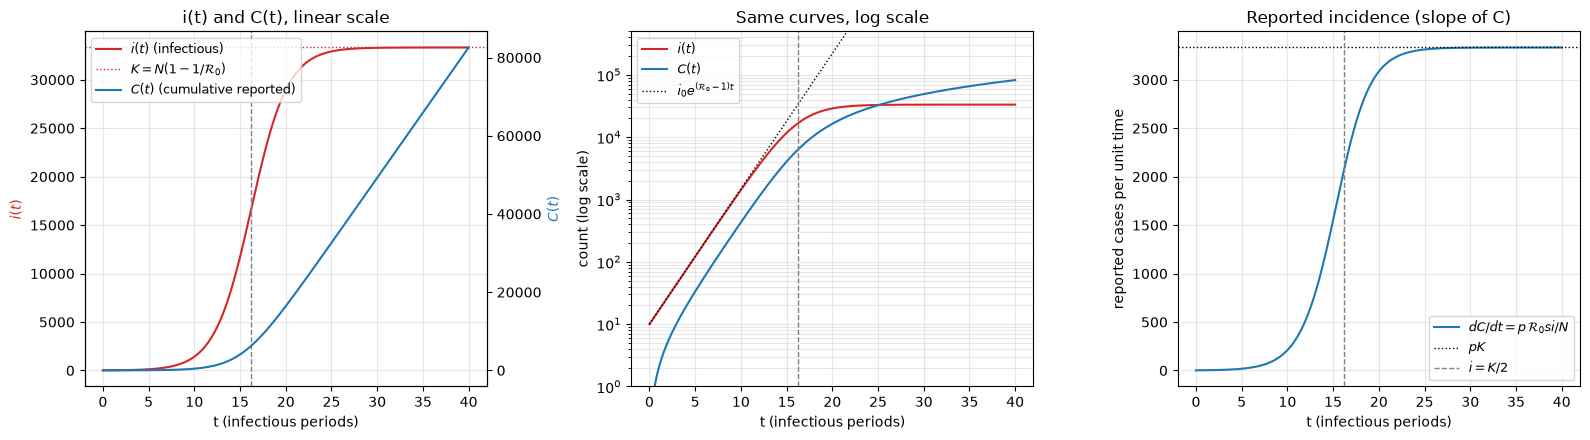

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# twin axes: C and i have very different magnitudes
ax = axes[0]
ax.plot(t, i_num, color="tab:red", label="$i(t)$ (infectious)")
ax.axhline(K, color="tab:red", ls=":", lw=1, label=r"$K = N(1 - 1/\mathcal{R}_0)$")
ax.set_xlabel("t (infectious periods)")
ax.set_ylabel("$i(t)$", color="tab:red")
ax2 = ax.twinx()
ax2.plot(t, C_num, color="tab:blue", label="$C(t)$ (cumulative reported)")
ax2.set_ylabel("$C(t)$", color="tab:blue")
ax.axvline(t_half, color="gray", ls="--", lw=1)
lines = ax.get_lines()[:2] + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=9)
ax.set_title("i(t) and C(t), linear scale")
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t, i_num, color="tab:red", label="$i(t)$")
ax.semilogy(t, C_num, color="tab:blue", label="$C(t)$")
ax.semilogy(t, i0 * np.exp((R0 - 1) * t), color="k", ls=":", lw=1,
            label=r"$i_0 e^{(\mathcal{R}_0 - 1)t}$")
ax.axvline(t_half, color="gray", ls="--", lw=1)
ax.set_ylim(1, 5e5)
ax.set_xlabel("t (infectious periods)")
ax.set_ylabel("count (log scale)")
ax.set_title("Same curves, log scale")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

ax = axes[2]
ax.plot(t, p * incidence(i_num), color="tab:blue", label=r"$dC/dt = p\,\mathcal{R}_0 s i / N$")
ax.axhline(p * K, color="k", ls=":", lw=1, label=r"$pK$")
ax.axvline(t_half, color="gray", ls="--", lw=1, label=r"$i = K/2$")
ax.set_xlabel("t (infectious periods)")
ax.set_ylabel("reported cases per unit time")
ax.set_title("Reported incidence (slope of C)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cases_vs_prevalence.png", dpi=150)
plt.show()

### Discussion

$C(t)$ has two regimes, with the transition around $t \approx 16$, where $i$ passes $K/2$ (dashed line).

**Regime 1: exponential growth ($t \lesssim 16$).** Almost everyone is susceptible, $s \approx N$, so $i \approx i_0 e^{(\mathcal{R}_0 - 1)t}$ and the incidence is $\approx \mathcal{R}_0 i$. Since $dC/dt \approx p\mathcal{R}_0 i$, $C$ is the integral of an exponential and grows exponentially at the same rate as $i$: the two are parallel lines on the log plot, with $C/i \approx p\mathcal{R}_0/(\mathcal{R}_0 - 1) = 0.3$ (measured 0.302 at $t = 10$).

**Regime 2: linear growth ($t \gtrsim 20$).** $i$ saturates at the endemic level $K \approx 33\,333$ and stays flat, but $C$ keeps growing linearly. A constant $i$ does not mean no new infections: at equilibrium $s^*/N = 1/\mathcal{R}_0$, so new infections $\mathcal{R}_0 s^* i^*/N = K$ exactly balance recoveries $\alpha i^* = K$. Since SIS gives no immunity, individuals keep being reinfected at rate $K$, and $C$ grows with constant slope $pK \approx 3\,333$ per unit time (fitted: 3333.1), as the plateau in the third panel shows.

In short, $i(t)$ is the number currently infectious (a stock), while $C(t)$ accumulates the flow of new infections: they track each other during growth, but once the epidemic is endemic $i$ is constant while $C$ keeps climbing.

### AI Use Declaration

**1. Did you use a generative AI tool while completing this assignment?** Yes.

**2. How did you use generative AI?**
- writing or revising code;
- interpreting data, results, tables, or plots;
- debugging code or interpreting error messages;
- clarifying concepts or checking your understanding.

**3. Sections or tasks where AI was used, and how it influenced our work.**
In A1.2, we used AI to review our derivation of $C(t)$ and the augmented ODE and to check the code for the RK4 integration of the augmented system.

**4. How did we verify the AI-generated suggestions, code, or explanations?**
We re-derived the integral and the $dC/dt$ equation by hand, checked the RK4 solution for $i$ against the closed form (3), and checked the numbers quoted in the discussion (transition time $t \approx 16.2$, late slope $\approx pK$, early ratio $C/i \approx 0.3$) against the printed outputs of the notebook.

**5. Confirmation.**
*I confirm that this declaration is complete and that I understand and can explain everything in my submission.*